# Импорт

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import pandas as pd
import tensorflow_datasets as tfds

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from sklearn.linear_model import SGDClassifier

# Загрузка

In [ ]:
(dataset_train, dataset_test), info = tfds.load(
    'cifar10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = info.features['label'].names
print(f"Классы: {class_names}")
print(f"Количество обучающих примеров: {info.splits['train'].num_examples}")
print(f"Количество тестовых примеров: {info.splits['test'].num_examples}")

Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Количество обучающих примеров: 50000
Количество тестовых примеров: 10000


In [ ]:
def ds_to_numpy(ds):
    images, labels = [], []
    for img, label in tfds.as_numpy(ds):
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

In [ ]:
print("Загрузка train...")
X_train_raw, y_train = ds_to_numpy(dataset_train)
print("Загрузка test...")
X_test_raw, y_test = ds_to_numpy(dataset_test)

X_train_raw = X_train_raw / 255.0
X_test_raw = X_test_raw / 255.0

print(f"Размер обучающей выборки: {X_train_raw.shape}")
print(f"Размер тестовой выборки: {X_test_raw.shape}")

Загрузка train...
Загрузка test...
Размер обучающей выборки: (50000, 32, 32, 3)
Размер тестовой выборки: (10000, 32, 32, 3)


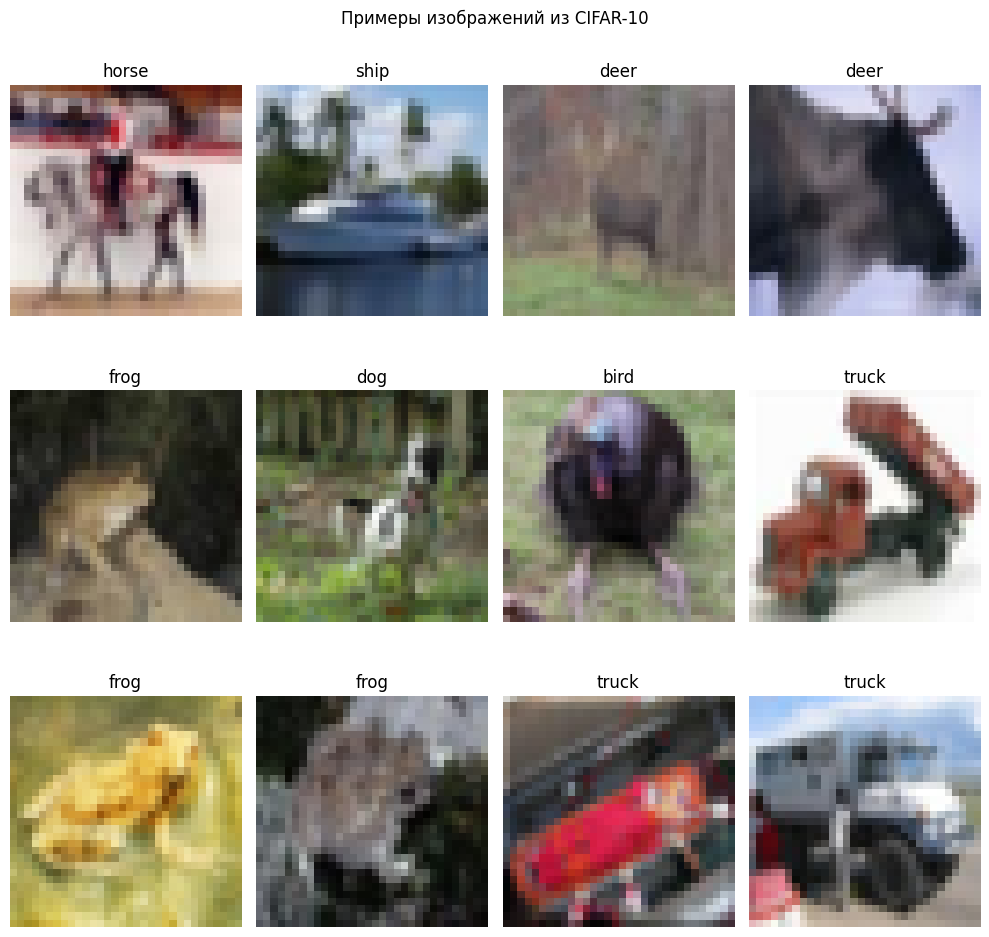

In [ ]:
plt.figure(figsize=(10,10))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train_raw[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Примеры изображений из CIFAR-10")
plt.tight_layout()
plt.show()

# Выделение признаков

In [ ]:
def to_grayscale(images):
    gray = np.array([rgb2gray(img) for img in images])
    return gray

In [ ]:
X_train_gray = to_grayscale(X_train_raw)
X_test_gray = to_grayscale(X_test_raw)

## HOG-признаки

In [ ]:
def extract_hog_cifar(images):
    features = []
    for img in images:
        fd = hog(img, orientations=9, pixels_per_cell=(4,4),
                 cells_per_block=(2,2), block_norm='L2-Hys', visualize=False)
        features.append(fd)
    return np.array(features)

In [ ]:
start_hog = time.time()
X_train_hog = extract_hog_cifar(X_train_gray)
X_test_hog = extract_hog_cifar(X_test_gray)
print(f"HOG извлечён за {time.time()-start_hog:.2f} сек. Размерность: {X_train_hog.shape[1]}")

HOG извлечён за 63.45 сек. Размерность: 1764


## LBP-признаки

In [ ]:
def extract_lbp_cifar(images, radius=2, n_points=8):
    features = []
    for img in images:
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points+3), density=True)
        features.append(hist)
    return np.array(features)

In [ ]:
start_lbp = time.time()
X_train_lbp = extract_lbp_cifar(X_train_gray)
X_test_lbp = extract_lbp_cifar(X_test_gray)
print(f"LBP извлечён за {time.time()-start_lbp:.2f} сек. Размерность: {X_train_lbp.shape[1]}")

LBP извлечён за 17.66 сек. Размерность: 10


# Подготовка данных

In [ ]:
X_tr_pix, X_val_pix, y_tr, y_val = train_test_split(
    X_train_raw.reshape(X_train_raw.shape[0], -1), y_train,
    test_size=0.2, random_state=42, stratify=y_train
)

X_tr_hog, X_val_hog, _, _ = train_test_split(
    X_train_hog, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_tr_lbp, X_val_lbp, _, _ = train_test_split(
    X_train_lbp, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
scaler_pix = StandardScaler()
X_tr_pix_scaled = scaler_pix.fit_transform(X_tr_pix)
X_val_pix_scaled = scaler_pix.transform(X_val_pix)
X_test_pix_scaled = scaler_pix.transform(X_test_raw.reshape(X_test_raw.shape[0], -1))

scaler_hog = StandardScaler()
X_tr_hog_scaled = scaler_hog.fit_transform(X_tr_hog)
X_val_hog_scaled = scaler_hog.transform(X_val_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

scaler_lbp = StandardScaler()
X_tr_lbp_scaled = scaler_lbp.fit_transform(X_tr_lbp)
X_val_lbp_scaled = scaler_lbp.transform(X_val_lbp)
X_test_lbp_scaled = scaler_lbp.transform(X_test_lbp)

# Модели

## Random Forest

In [ ]:
def train_evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"{model_name}: Время обучения = {train_time:.2f} сек, "
          f"Train acc = {train_acc:.4f}, Val acc = {val_acc:.4f}")
    return model, train_time, val_acc

In [ ]:
sample_size = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(y_tr), sample_size, replace=False)

In [ ]:
n_estimators_list = [20, 30, 50, 80]
best_n = 30
best_val_acc = 0
for n in n_estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n, max_depth=15, random_state=42, n_jobs=-1)
    rf_temp.fit(X_tr_hog_scaled[sample_idx], y_tr[sample_idx])
    val_acc = accuracy_score(y_val, rf_temp.predict(X_val_hog_scaled))
    print(f"  n={n}: val acc = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_n = n
print(f"Лучшее n_estimators: {best_n}")

  n=20: val acc = 0.2967
  n=30: val acc = 0.3206
  n=50: val acc = 0.3594
  n=80: val acc = 0.3873
Лучшее n_estimators: 80


In [ ]:
best_n = 80
rf_pix = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
rf_hog = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
rf_lbp = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)

In [ ]:
train_evaluate_model(rf_pix, X_tr_pix_scaled[sample_idx], y_tr[sample_idx], X_val_pix_scaled, y_val, "RF (пиксели)")
train_evaluate_model(rf_hog, X_tr_hog_scaled[sample_idx], y_tr[sample_idx], X_val_hog_scaled, y_val, "RF (HOG)")
train_evaluate_model(rf_lbp, X_tr_lbp_scaled[sample_idx], y_tr[sample_idx], X_val_lbp_scaled, y_val, "RF (LBP)")

RF (пиксели): Время обучения = 41.49 сек, Train acc = 1.0000, Val acc = 0.4095
RF (HOG): Время обучения = 31.14 сек, Train acc = 1.0000, Val acc = 0.3780
RF (LBP): Время обучения = 3.24 сек, Train acc = 1.0000, Val acc = 0.2638


(RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=42),
 3.244985342025757,
 0.2638)

## SGDClassifier

In [ ]:
param_grid = [
    {'alpha': 0.0001, 'penalty': 'l2'},
    {'alpha': 0.001, 'penalty': 'l2'},
    {'alpha': 0.0001, 'penalty': 'l1'},
]
best_sgd_params = {'alpha': 0.0001, 'penalty': 'l2'}
best_val_acc_sgd = 0
for params in param_grid:
    sgd_temp = SGDClassifier(loss='hinge', max_iter=1000, random_state=42,
                             alpha=params['alpha'], penalty=params['penalty'])
    sgd_temp.fit(X_tr_hog_scaled[sample_idx], y_tr[sample_idx])
    val_acc = accuracy_score(y_val, sgd_temp.predict(X_val_hog_scaled))
    print(f"  alpha={params['alpha']}, penalty={params['penalty']}: val acc = {val_acc:.4f}")
    if val_acc > best_val_acc_sgd:
        best_val_acc_sgd = val_acc
        best_sgd_params = params
print(f"Лучшие параметры SGD: {best_sgd_params}")

  alpha=0.0001, penalty=l2: val acc = 0.3964
  alpha=0.001, penalty=l2: val acc = 0.4755
  alpha=0.0001, penalty=l1: val acc = 0.4365
Лучшие параметры SGD: {'alpha': 0.001, 'penalty': 'l2'}


In [ ]:
sgd_pix = SGDClassifier(loss='hinge', max_iter=1000, random_state=42,
                        alpha=best_sgd_params['alpha'], penalty=best_sgd_params['penalty'])
sgd_hog = SGDClassifier(loss='hinge', max_iter=1000, random_state=42,
                        alpha=best_sgd_params['alpha'], penalty=best_sgd_params['penalty'])
sgd_lbp = SGDClassifier(loss='hinge', max_iter=1000, random_state=42,
                        alpha=best_sgd_params['alpha'], penalty=best_sgd_params['penalty'])

In [ ]:
train_evaluate_model(sgd_pix, X_tr_pix_scaled[sample_idx], y_tr[sample_idx], X_val_pix_scaled, y_val, "SGD (пиксели)")
train_evaluate_model(sgd_hog, X_tr_hog_scaled[sample_idx], y_tr[sample_idx], X_val_hog_scaled, y_val, "SGD (HOG)")
train_evaluate_model(sgd_lbp, X_tr_lbp_scaled[sample_idx], y_tr[sample_idx], X_val_lbp_scaled, y_val, "SGD (LBP)")

SGD (пиксели): Время обучения = 454.23 сек, Train acc = 0.4447, Val acc = 0.3629
SGD (HOG): Время обучения = 251.13 сек, Train acc = 0.6245, Val acc = 0.4755
SGD (LBP): Время обучения = 0.23 сек, Train acc = 0.1374, Val acc = 0.1393


(SGDClassifier(alpha=0.001, random_state=42), 0.23022890090942383, 0.1393)

# Финальные результаты на тестовой выборке

In [ ]:
models = {
    "RF (pixels)": (rf_pix, X_test_pix_scaled),
    "RF (HOG)": (rf_hog, X_test_hog_scaled),
    "RF (LBP)": (rf_lbp, X_test_lbp_scaled),
    "SGD (pixels)": (sgd_pix, X_test_pix_scaled),
    "SGD (HOG)": (sgd_hog, X_test_hog_scaled),
    "SGD (LBP)": (sgd_lbp, X_test_lbp_scaled)
}

test_results = {}
for name, (model, X_te) in models.items():
    pred = model.predict(X_te)
    acc = accuracy_score(y_test, pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, pred, average='macro'
    )
    test_results[name] = {'accuracy': acc, 'recall_macro': recall_macro, 'f1_macro': f1_macro}

df_results = pd.DataFrame(test_results).T
print(df_results)

              accuracy  recall_macro  f1_macro
RF (pixels)     0.4168        0.4168  0.414086
RF (HOG)        0.3755        0.3755  0.372175
RF (LBP)        0.2670        0.2670  0.263786
SGD (pixels)    0.3659        0.3659  0.369134
SGD (HOG)       0.4648        0.4648  0.468400
SGD (LBP)       0.1394        0.1394  0.107680


# Анализ ошибок

In [ ]:
best_model_name = max(test_results, key=lambda x: test_results[x]['f1_macro'])
best_model, best_X_test = models[best_model_name]
print(f"Лучшая модель: {best_model_name}")
print(f"  Accuracy = {test_results[best_model_name]['accuracy']:.4f}")
print(f"  Recall (macro) = {test_results[best_model_name]['recall_macro']:.4f}")
print(f"  F1 (macro) = {test_results[best_model_name]['f1_macro']:.4f}")

y_pred_best = best_model.predict(best_X_test)

Лучшая модель: SGD (HOG)
  Accuracy = 0.4648
  Recall (macro) = 0.4648
  F1 (macro) = 0.4684


## Матрица ошибок

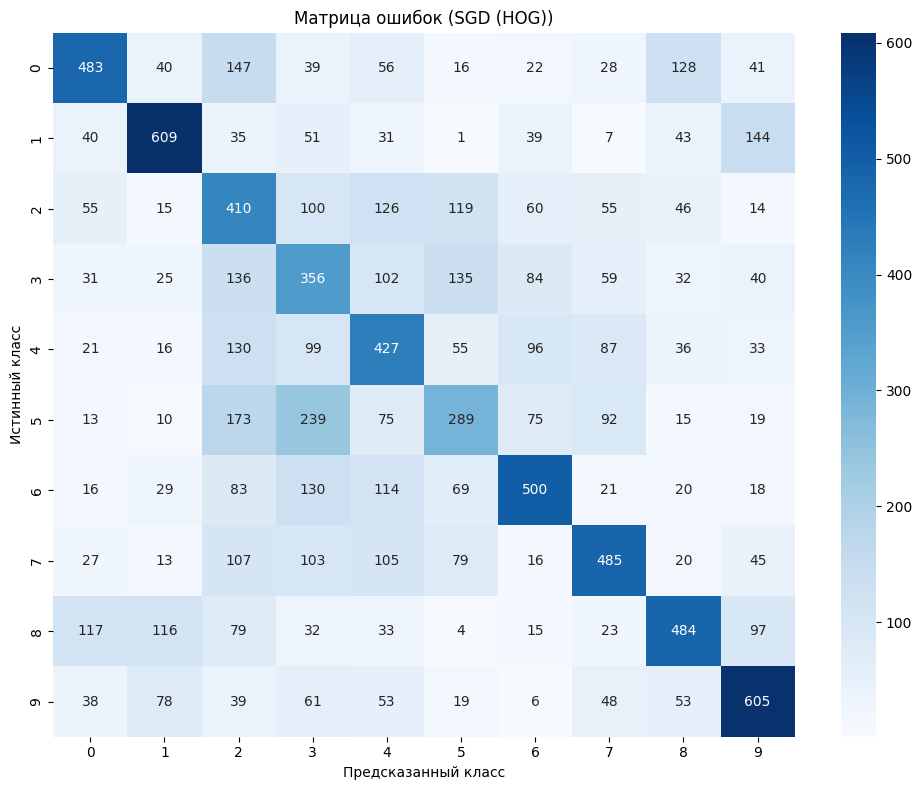

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f"Матрица ошибок ({best_model_name})")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

## Примеры

In [ ]:
def plot_examples(indices, title, n=6):
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(indices[:n]):
        plt.subplot(2,3,i+1)
        plt.imshow(X_test_raw[idx])
        true_label = class_names[y_test[idx]]
        pred_label = class_names[y_pred_best[idx]]
        color = 'green' if y_test[idx] == y_pred_best[idx] else 'red'
        plt.title(f"Истина: {true_label}\nПредск: {pred_label}", color=color)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

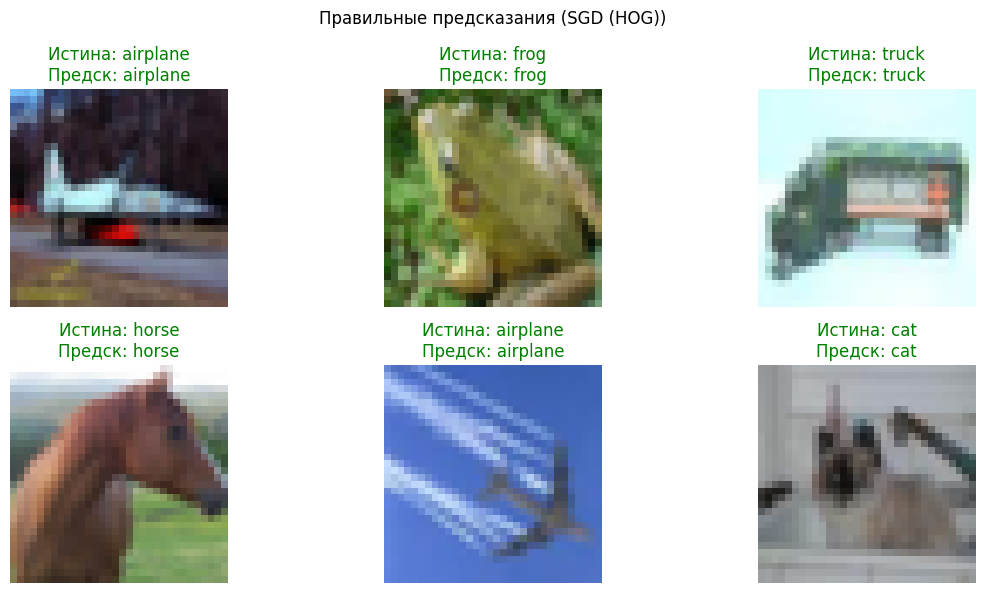

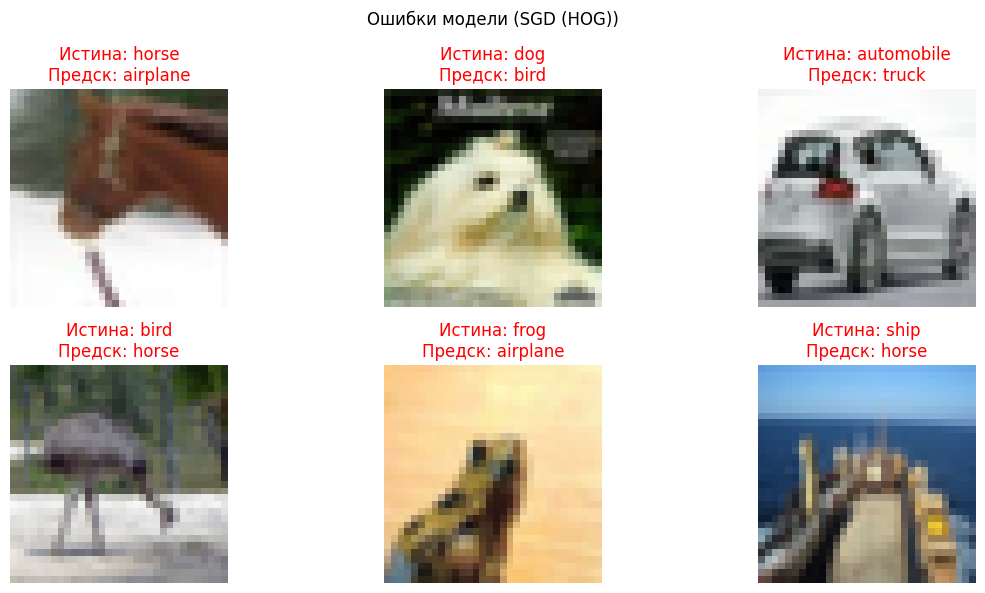


Самые частые путаницы (SGD (HOG)):
  dog -> cat : 239 раз(а)
  dog -> bird : 173 раз(а)
  airplane -> bird : 147 раз(а)
  automobile -> truck : 144 раз(а)
  cat -> bird : 136 раз(а)


In [ ]:
correct_idx = np.where(y_pred_best == y_test)[0]
wrong_idx = np.where(y_pred_best != y_test)[0]
plot_examples(correct_idx, f"Правильные предсказания ({best_model_name})", n=6)
plot_examples(wrong_idx, f"Ошибки модели ({best_model_name})", n=6)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top_errors = []
for _ in range(5):
    idx = np.argmax(cm_no_diag)
    i, j = idx // 10, idx % 10
    top_errors.append((i, j, cm_no_diag[i, j]))
    cm_no_diag[i, j] = 0

print(f"\nСамые частые путаницы ({best_model_name}):")
for true_cls, pred_cls, count in top_errors:
    print(f"  {class_names[true_cls]} -> {class_names[pred_cls]} : {count} раз(а)")